In [10]:
import xarray as xr

ds = xr.load_dataset("transect_SOCAT_only_140E_143E_lat_min_to30S_monthly.nc")

In [11]:
ds

<xarray.Dataset> Size: 534kB
Dimensions:    (time: 327, lat: 29)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1997-09-01 1997-10-01 ... 2024-12-01
  * lat        (lat) float64 232B -67.0 -66.0 -65.0 -64.0 ... -41.0 -40.0 -39.0
Data variables:
    temp       (time, lat) float64 76kB -1.845 nan nan ... 15.47 15.98 17.11
    sal        (time, lat) float64 76kB 34.3 nan nan 34.05 ... 35.03 35.19 35.33
    wind       (time, lat) float64 76kB 6.134 nan nan ... 4.996 4.289 3.559
    pco2_pred  (time, lat) float64 76kB 403.2 nan nan ... 367.4 378.0 388.5
    pco2_std   (time, lat) float64 76kB 20.0 nan nan 13.12 ... 6.308 6.938 7.703
    flux       (time, lat) float64 76kB 0.08153 nan nan ... -0.0556 -0.0348
    n_cells    (time, lat) float64 76kB 2.0 nan nan 2.0 4.0 ... 4.0 4.0 4.0 3.0
Attributes:
    source:          SOCAT-only predictions
    lon_band_E:      140.0–143.0
    lat_range_degN:  -67.0–-39.0
    note:            Lon-averaged transect (NOT area-integrated). Monthly mea...

/home/ldelaigue/.conda/envs/soca/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


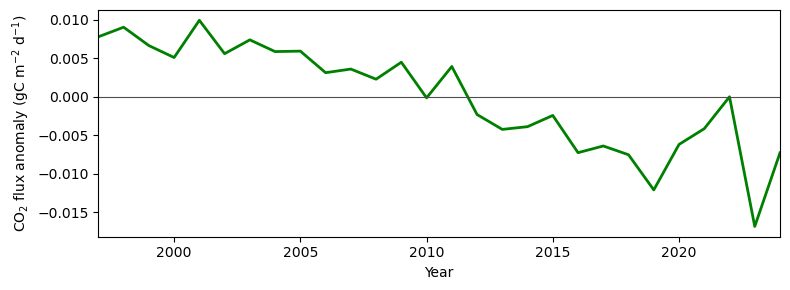

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset("transect_SOCAT_only_140E_143E_lat_min_to30S_monthly.nc")
F = ds["flux"]  # gC m-2 d-1

# ---- area-weighted lat mean ----
w = np.cos(np.deg2rad(F["lat"]))
F_latmean = F.weighted(w).mean("lat")

# ---- yearly mean ----
F_year = F_latmean.resample(time="1Y").mean()

# use year as x-axis
years = F_year["time"].dt.year

# ---- remove mean to get anomaly ----
F_anom = F_year - F_year.mean("time")

# ---- plot ----
fig, ax = plt.subplots(figsize=(8,3))

ax.plot(years, F_anom, color="green", lw=2)

ax.axhline(0, color="0.3", lw=0.8)
ax.set_ylabel("CO$_2$ flux anomaly (gC m$^{-2}$ d$^{-1}$)")
ax.set_xlabel("Year")
ax.margins(x=0)

plt.tight_layout()
plt.show()

In [6]:
sofloats = xr.load_dataset("transect_SOCATplusFLOATS_weighted_140E_143E_lat_min_to30S_monthly.nc")

In [8]:
sofloats.flux

<xarray.DataArray 'flux' (time: 327, lat: 29)> Size: 76kB
array([[ 0.07310495,         nan,         nan, ..., -0.0138486 ,
        -0.01606157, -0.01494098],
       [ 0.02364417,         nan,         nan, ..., -0.05715117,
        -0.04759137, -0.03176703],
       [-0.01412769,  0.00748143,  0.00061662, ..., -0.05234535,
        -0.03747366, -0.01533863],
       ...,
       [ 0.00889377,         nan,         nan, ..., -0.03882773,
        -0.03750033, -0.03211073],
       [-0.04244534, -0.04943303,         nan, ..., -0.0131071 ,
        -0.0105564 , -0.01016221],
       [-0.1021054 , -0.05873803, -0.07238259, ..., -0.08369083,
        -0.05737581, -0.02671855]], shape=(327, 29))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1997-09-01 1997-10-01 ... 2024-12-01
  * lat      (lat) float64 232B -67.0 -66.0 -65.0 -64.0 ... -41.0 -40.0 -39.0
Attributes:
    long_name:  Air-sea CO2 flux (bulk)
    units:      gC m-2 d-1

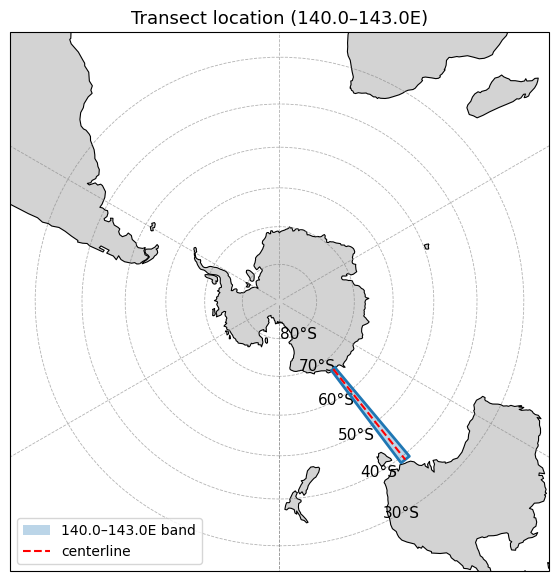

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_transect_map(
    ds,
    lon_min=140.0,
    lon_max=143.0,
    lat_name="lat",
    title=None,
):

    lats = ds[lat_name].values.astype(float)
    lats = lats[np.isfinite(lats)]

    # Convert lon to [-180,180] for plotting
    lon_min_plot = ((lon_min + 180) % 360) - 180
    lon_max_plot = ((lon_max + 180) % 360) - 180
    lon_mid = ((lon_min + lon_max) / 2.0 + 180) % 360 - 180

    # Build swath polygon
    lats_sorted = np.sort(lats)
    lons1 = np.full_like(lats_sorted, lon_min_plot)
    lons2 = np.full_like(lats_sorted, lon_max_plot)

    poly_lons = np.concatenate([lons1, lons2[::-1], [lons1[0]]])
    poly_lats = np.concatenate([lats_sorted, lats_sorted[::-1], [lats_sorted[0]]])

    # --- Map ---
    proj = ccrs.SouthPolarStereo()
    fig = plt.figure(figsize=(7, 7))
    ax = plt.axes(projection=proj)

    ax.set_extent([-180, 180, -90, -25], crs=ccrs.PlateCarree())

    # Features
    ax.add_feature(cfeature.LAND, zorder=0, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor="white")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    # --- Gridlines with latitude labels ---
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.6,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )

    # Only show latitude labels (left side)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True

    # Set specific latitude lines so -30 is obvious
    gl.ylocator = plt.FixedLocator([-80, -70, -60, -50, -40, -30])
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 11}

    # Swath
    ax.fill(
        poly_lons, poly_lats,
        transform=ccrs.PlateCarree(),
        alpha=0.3,
        zorder=3,
        label=f"{lon_min}–{lon_max}E band"
    )
    ax.plot(
        poly_lons, poly_lats,
        transform=ccrs.PlateCarree(),
        linewidth=2.0,
        zorder=4
    )

    # Centerline
    ax.plot(
        np.full_like(lats_sorted, lon_mid), lats_sorted,
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        linestyle="--",
        color="red",
        label="centerline",
        zorder=5
    )

    if title is None:
        title = f"Transect location ({lon_min}–{lon_max}E)"
    ax.set_title(title, fontsize=13)

    ax.legend(loc="lower left")
    plt.show()


# Run:
plot_transect_map(sofloats, lon_min=140.0, lon_max=143.0)